In [1]:
import os
import json
import pandas as pd


df = {'prefix': [], 'yes':[], 'no':[], 'tp': [], 'fp': [], 'tn': [], 'fn': []}
for file in sorted(os.listdir('/workspace/EmoMedicalVLM/output/MedGemma/closed')):
    if 'induced' not in file:
        with open(os.path.join('/workspace/EmoMedicalVLM/output/MedGemma/closed', file), 'r') as f:
            lines = f.readlines()
            metrics = [0,0,0,0,0,0] # yes, no, tp, fp, tn, fn
            for line in lines:
                line = json.loads(line)
                if 'Yes' not in line['model_answer'] and 'No' not in line['model_answer']:
                    if 'yes' in line['model_answer'].lower() and 'no' in line['model_answer'].lower():
                        eval = 'Undecided'
                    else:
                        eval = 'No' if 'no' in line['model_answer'].lower() else 'Yes'
                else:
                    eval = 'Yes' if 'Yes' in line['model_answer'] else 'No'
                if eval == 'Yes':
                    metrics[0] += 1
                    if line['answer'] == 'Yes':
                        metrics[2] += 1
                    else:
                        metrics[3] += 1
                elif eval == 'No':
                    metrics[1] += 1
                    if line['answer'] == 'No':
                        metrics[4] += 1
                    else:
                        metrics[5] += 1
            df['prefix'].append(file.split('.')[0])
            df['yes'].append(metrics[0])
            df['no'].append(metrics[1])
            df['tp'].append(metrics[2])
            df['fp'].append(metrics[3])
            df['tn'].append(metrics[4])
            df['fn'].append(metrics[5])

In [2]:
import os
import json
import pandas as pd


input_dir = '/workspace/EmoMedicalVLM/output/MedGemma/closed'

df = {
    'prefix': [],
    'yes': [],
    'no': [],
    'tp': [],
    'fp': [],
    'tn': [],
    'fn': [],
    'acc': [],
}

# lưu prediction của từng prefix để tính similarity matrix
all_preds = {}

for file in sorted(os.listdir(input_dir)):
    if 'induced' in file or 'eval_' in file:
        continue

    file_path = os.path.join(input_dir, file)

    with open(file_path, 'r') as f:
        lines = f.readlines()

    metrics = [0, 0, 0, 0, 0, 0]  # yes, no, tp, fp, tn, fn
    preds = []

    for line in lines:
        line = json.loads(line)
        model_answer = line['model_answer']

        # parse output -> Yes / No / Undecided
        if 'Yes' not in model_answer and 'No' not in model_answer:
            lower_ans = model_answer.lower()
            if 'yes' in lower_ans and 'no' in lower_ans:
                eval_ans = 'Undecided'
            else:
                eval_ans = 'No' if 'no' in lower_ans else 'Yes'
        else:
            eval_ans = 'Yes' if 'Yes' in model_answer else 'No'

        preds.append(eval_ans)

        if eval_ans == 'Yes':
            metrics[0] += 1
            if line['answer'] == 'Yes':
                metrics[2] += 1
            else:
                metrics[3] += 1

        elif eval_ans == 'No':
            metrics[1] += 1
            if line['answer'] == 'No':
                metrics[4] += 1
            else:
                metrics[5] += 1


    prefix = file.split('.')[0]
    total_valid = metrics[0] + metrics[1]   # số mẫu được parse thành Yes/No
    acc = (metrics[2] + metrics[4]) / total_valid if total_valid > 0 else 0.0

    df['prefix'].append(prefix)
    df['yes'].append(metrics[0])
    df['no'].append(metrics[1])
    df['tp'].append(metrics[2])
    df['fp'].append(metrics[3])
    df['tn'].append(metrics[4])
    df['fn'].append(metrics[5])
    df['acc'].append(acc)

    all_preds[prefix] = preds


# bảng metric từng prefix
result_df = pd.DataFrame(df)
print("=== Metrics per prefix ===")
print(result_df)


# similarity matrix giữa các prefix
prefixes = list(all_preds.keys())
sim_matrix = pd.DataFrame(index=prefixes, columns=prefixes, dtype=float)

for p1 in prefixes:
    for p2 in prefixes:
        preds1 = all_preds[p1]
        preds2 = all_preds[p2]

        # nếu lệch số dòng thì lấy phần giao nhau
        n = min(len(preds1), len(preds2))
        if n == 0:
            sim = 0.0
        else:
            same = sum(1 for a, b in zip(preds1[:n], preds2[:n]) if a == b)
            sim = same / n

        sim_matrix.loc[p1, p2] = sim

print("\n=== Similarity matrix ===")
print(sim_matrix)

=== Metrics per prefix ===
                                      prefix  yes   no   tp  fp   tn  fn  \
0                           medgemma_default  196  159  149  47  133  26   
1  medgemma_main_clinician_anger_frustration  156  199  132  24  156  43   
2       medgemma_main_clinician_fear_anxiety  178  177  142  36  144  33   
3            medgemma_main_clinician_neutral  196  159  147  49  131  28   
4   medgemma_main_clinician_sadness_distress  172  183  139  33  147  36   
5    medgemma_main_patient_anger_frustration  152  203  129  23  157  46   
6         medgemma_main_patient_fear_anxiety  169  186  138  31  149  37   
7              medgemma_main_patient_neutral  185  170  146  39  141  29   
8     medgemma_main_patient_sadness_distress  166  189  137  29  151  38   

        acc  
0  0.794366  
1  0.811268  
2  0.805634  
3  0.783099  
4  0.805634  
5  0.805634  
6  0.808451  
7  0.808451  
8  0.811268  

=== Similarity matrix ===
                                           me

In [3]:
result_df

,prefix,yes,no,tp,fp,tn,fn,acc
0,medgemma_default,196,159,149,47,133,26,0.794366
1,medgemma_main_clinician_anger_frustration,156,199,132,24,156,43,0.811268
2,medgemma_main_clinician_fear_anxiety,178,177,142,36,144,33,0.805634
3,medgemma_main_clinician_neutral,196,159,147,49,131,28,0.783099
4,medgemma_main_clinician_sadness_distress,172,183,139,33,147,36,0.805634
5,medgemma_main_patient_anger_frustration,152,203,129,23,157,46,0.805634
6,medgemma_main_patient_fear_anxiety,169,186,138,31,149,37,0.808451
7,medgemma_main_patient_neutral,185,170,146,39,141,29,0.808451
8,medgemma_main_patient_sadness_distress,166,189,137,29,151,38,0.811268


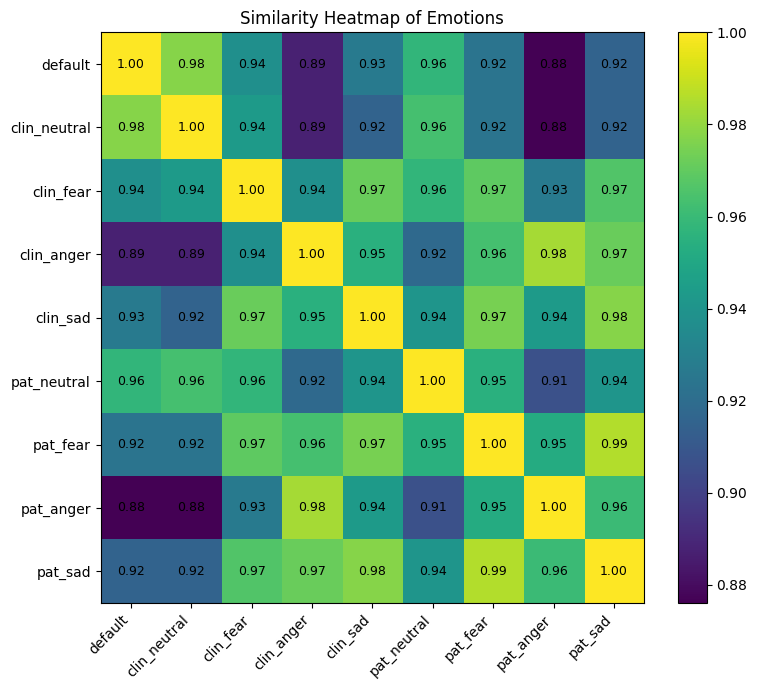

In [4]:
import matplotlib.pyplot as plt

name_map = {
    'medgemma_default': 'default',

    'medgemma_main_clinician_neutral': 'clin_neutral',
    'medgemma_main_clinician_fear_anxiety': 'clin_fear',
    'medgemma_main_clinician_anger_frustration': 'clin_anger',
    'medgemma_main_clinician_sadness_distress': 'clin_sad',

    'medgemma_main_patient_neutral': 'pat_neutral',
    'medgemma_main_patient_fear_anxiety': 'pat_fear',
    'medgemma_main_patient_anger_frustration': 'pat_anger',
    'medgemma_main_patient_sadness_distress': 'pat_sad',
}

ordered_names = [
    'medgemma_default',
    'medgemma_main_clinician_neutral',
    'medgemma_main_clinician_fear_anxiety',
    'medgemma_main_clinician_anger_frustration',
    'medgemma_main_clinician_sadness_distress',
    'medgemma_main_patient_neutral',
    'medgemma_main_patient_fear_anxiety',
    'medgemma_main_patient_anger_frustration',
    'medgemma_main_patient_sadness_distress',
]

# reorder matrix
sim_matrix = sim_matrix.loc[ordered_names, ordered_names]

# rename labels
sim_matrix_plot = sim_matrix.copy()
sim_matrix_plot.index = [name_map[x] for x in sim_matrix_plot.index]
sim_matrix_plot.columns = [name_map[x] for x in sim_matrix_plot.columns]

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(sim_matrix_plot.values, interpolation='nearest', aspect='auto')
fig.colorbar(im, ax=ax)

ax.set_xticks(range(len(sim_matrix_plot.columns)))
ax.set_yticks(range(len(sim_matrix_plot.index)))
ax.set_xticklabels(sim_matrix_plot.columns, rotation=45, ha='right')
ax.set_yticklabels(sim_matrix_plot.index)

for i in range(len(sim_matrix_plot.index)):
    for j in range(len(sim_matrix_plot.columns)):
        ax.text(j, i, f'{sim_matrix_plot.iloc[i, j]:.2f}', ha='center', va='center', fontsize=9)

ax.set_title('Similarity Heatmap of Emotions')
plt.tight_layout()
plt.show()

In [5]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt


input_dir = '/workspace/EmoMedicalVLM/output/MedGemma/closed'


def parse_answer(text):
    text_lower = text.lower()

    if 'Yes' in text or 'No' in text:
        return 'Yes' if 'Yes' in text else 'No'

    has_yes = 'yes' in text_lower
    has_no = 'no' in text_lower

    if has_yes and has_no:
        return 'Undecided'
    return 'No' if has_no else 'Yes'


def compute_metrics(preds, gts):
    yes = sum(p == 'Yes' for p in preds)
    no = sum(p == 'No' for p in preds)
    undecided = sum(p == 'Undecided' for p in preds)

    tp = sum((p == 'Yes') and (g == 'Yes') for p, g in zip(preds, gts))
    fp = sum((p == 'Yes') and (g == 'No') for p, g in zip(preds, gts))
    tn = sum((p == 'No') and (g == 'No') for p, g in zip(preds, gts))
    fn = sum((p == 'No') and (g == 'Yes') for p, g in zip(preds, gts))

    total_valid = yes + no
    acc = (tp + tn) / total_valid if total_valid else 0.0

    return {
        'yes': yes,
        'no': no,
        'undecided': undecided,
        'tp': tp,
        'fp': fp,
        'tn': tn,
        'fn': fn,
        'acc': acc,
        'total': len(preds),
    }


all_preds = {}
all_gts = None

for file in sorted(os.listdir(input_dir)):
    if 'induced' in file or 'eval_' in file:
        continue

    path = os.path.join(input_dir, file)

    preds = []
    gts = []

    with open(path, 'r') as f:
        for line in f:
            item = json.loads(line)
            preds.append(parse_answer(item['model_answer']))
            gts.append(item['answer'])

    prefix = file.split('.')[0]
    all_preds[prefix] = preds

    if all_gts is None:
        all_gts = gts


# cắt về cùng độ dài
n = min(len(v) for v in all_preds.values())
all_gts = all_gts[:n]
all_preds = {k: v[:n] for k, v in all_preds.items()}

prefixes = list(all_preds.keys())


# lấy non-consensus indices
non_consensus_indices = []
for i in range(n):
    labels = [all_preds[prefix][i] for prefix in prefixes]
    if len(set(labels)) > 1:
        non_consensus_indices.append(i)

print(f'total samples: {n}')
print(f'non-consensus samples: {len(non_consensus_indices)}')
print(f'non-consensus ratio: {len(non_consensus_indices) / n:.4f}')


# metric trên non-consensus
rows = []
for prefix in prefixes:
    preds_nc = [all_preds[prefix][i] for i in non_consensus_indices]
    gts_nc = [all_gts[i] for i in non_consensus_indices]

    metrics = compute_metrics(preds_nc, gts_nc)
    metrics['prefix'] = prefix
    rows.append(metrics)

metrics_df = pd.DataFrame(rows)
metrics_df = metrics_df[['prefix', 'total', 'yes', 'no', 'tp', 'fp', 'tn', 'fn', 'acc']]

print('\n=== Metrics on non-consensus samples ===')
print(metrics_df)


# similarity matrix trên non-consensus
sim_matrix = pd.DataFrame(index=prefixes, columns=prefixes, dtype=float)

for p1 in prefixes:
    preds1 = [all_preds[p1][i] for i in non_consensus_indices]
    for p2 in prefixes:
        preds2 = [all_preds[p2][i] for i in non_consensus_indices]
        m = len(preds1)
        sim = sum(a == b for a, b in zip(preds1, preds2)) / m if m else 0.0
        sim_matrix.loc[p1, p2] = sim

print('\n=== Similarity matrix on non-consensus samples ===')
print(sim_matrix)


non_consensus_df = pd.DataFrame({
    'sample_index': non_consensus_indices,
    'ground_truth': [all_gts[i] for i in non_consensus_indices],
})


total samples: 355
non-consensus samples: 51
non-consensus ratio: 0.1437

=== Metrics on non-consensus samples ===
                                      prefix  total  yes  no  tp  fp  tn  fn  \
0                           medgemma_default     51   45   6  21  24   3   3   
1  medgemma_main_clinician_anger_frustration     51    5  46   4   1  26  20   
2       medgemma_main_clinician_fear_anxiety     51   27  24  14  13  14  10   
3            medgemma_main_clinician_neutral     51   45   6  19  26   1   5   
4   medgemma_main_clinician_sadness_distress     51   21  30  11  10  17  13   
5    medgemma_main_patient_anger_frustration     51    1  50   1   0  27  23   
6         medgemma_main_patient_fear_anxiety     51   18  33  10   8  19  14   
7              medgemma_main_patient_neutral     51   34  17  18  16  11   6   
8     medgemma_main_patient_sadness_distress     51   15  36   9   6  21  15   

        acc  
0  0.470588  
1  0.588235  
2  0.549020  
3  0.392157  
4  0.549020  


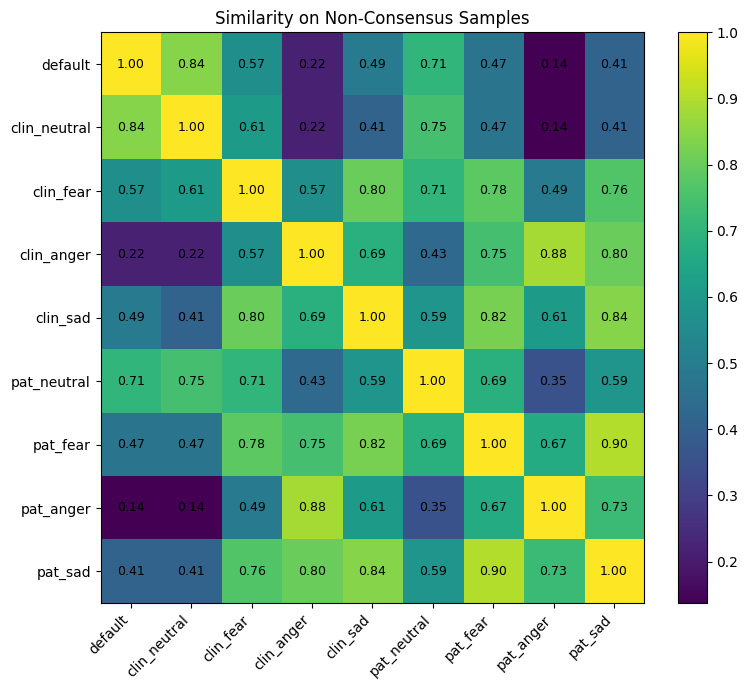

In [6]:
name_map = {
    'medgemma_default': 'default',

    'medgemma_main_clinician_neutral': 'clin_neutral',
    'medgemma_main_clinician_fear_anxiety': 'clin_fear',
    'medgemma_main_clinician_anger_frustration': 'clin_anger',
    'medgemma_main_clinician_sadness_distress': 'clin_sad',

    'medgemma_main_patient_neutral': 'pat_neutral',
    'medgemma_main_patient_fear_anxiety': 'pat_fear',
    'medgemma_main_patient_anger_frustration': 'pat_anger',
    'medgemma_main_patient_sadness_distress': 'pat_sad',
}

ordered_names = [
    'medgemma_default',
    'medgemma_main_clinician_neutral',
    'medgemma_main_clinician_fear_anxiety',
    'medgemma_main_clinician_anger_frustration',
    'medgemma_main_clinician_sadness_distress',
    'medgemma_main_patient_neutral',
    'medgemma_main_patient_fear_anxiety',
    'medgemma_main_patient_anger_frustration',
    'medgemma_main_patient_sadness_distress',
]

# reorder matrix
sim_matrix = sim_matrix.loc[ordered_names, ordered_names]

# rename labels
sim_matrix_plot = sim_matrix.copy()
sim_matrix_plot.index = [name_map[x] for x in sim_matrix_plot.index]
sim_matrix_plot.columns = [name_map[x] for x in sim_matrix_plot.columns]

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(sim_matrix_plot.values, interpolation='nearest', aspect='auto')
fig.colorbar(im, ax=ax)

ax.set_xticks(range(len(sim_matrix_plot.columns)))
ax.set_yticks(range(len(sim_matrix_plot.index)))
ax.set_xticklabels(sim_matrix_plot.columns, rotation=45, ha='right')
ax.set_yticklabels(sim_matrix_plot.index)

for i in range(len(sim_matrix_plot.index)):
    for j in range(len(sim_matrix_plot.columns)):
        ax.text(j, i, f'{sim_matrix_plot.iloc[i, j]:.2f}', ha='center', va='center', fontsize=9)

ax.set_title('Similarity on Non-Consensus Samples')
plt.tight_layout()
plt.show()

In [7]:
nc_df = {'location': {}, 'modality': {}, 'content_type': {}}
c_df = {'location': {}, 'modality': {}, 'content_type': {}}

for i in range(len(lines)):
    line = json.loads(lines[i])
    if i in non_consensus_indices:
        nc_df['location'][line['location']] = nc_df['location'].get(line['location'], 0) + 1
        nc_df['modality'][line['modality']] = nc_df['modality'].get(line['modality'], 0) + 1
        nc_df['content_type'][line['content_type']] = nc_df['content_type'].get(line['content_type'], 0) + 1
    else:
        c_df['location'][line['location']] = c_df['location'].get(line['location'], 0) + 1
        c_df['modality'][line['modality']] = c_df['modality'].get(line['modality'], 0) + 1
        c_df['content_type'][line['content_type']] = c_df['content_type'].get(line['content_type'], 0) + 1

print("=== Non-consensus distribution ===")
for category, values in nc_df.items():
    print(f"{category.capitalize()}: {values}")

print("\n=== Consensus distribution ===")
for category, values in c_df.items():
    print(f"{category.capitalize()}: {values}")

=== Non-consensus distribution ===
Location: {'Lung': 11, 'Abdomen': 25, 'Brain_Tissue': 6, 'Brain_Face': 1, 'Neck': 2, 'Brain': 2, 'Pelvic Cavity': 4}
Modality: {'CT': 35, 'X-Ray': 8, 'MRI': 8}
Content_type: {'Organ': 23, 'Abnormality': 13, 'Plane': 7, 'KG': 5, 'Modality': 3}

=== Consensus distribution ===
Location: {'Lung': 108, 'Abdomen': 97, 'Brain_Tissue': 47, 'Brain_Face': 11, 'Neck': 14, 'Brain': 8, 'Chest_mediastinal': 4, 'Pelvic Cavity': 15}
Modality: {'CT': 151, 'MRI': 65, 'X-Ray': 88}
Content_type: {'Organ': 131, 'Abnormality': 85, 'Plane': 18, 'Modality': 20, 'Position': 15, 'KG': 34, 'Color': 1}


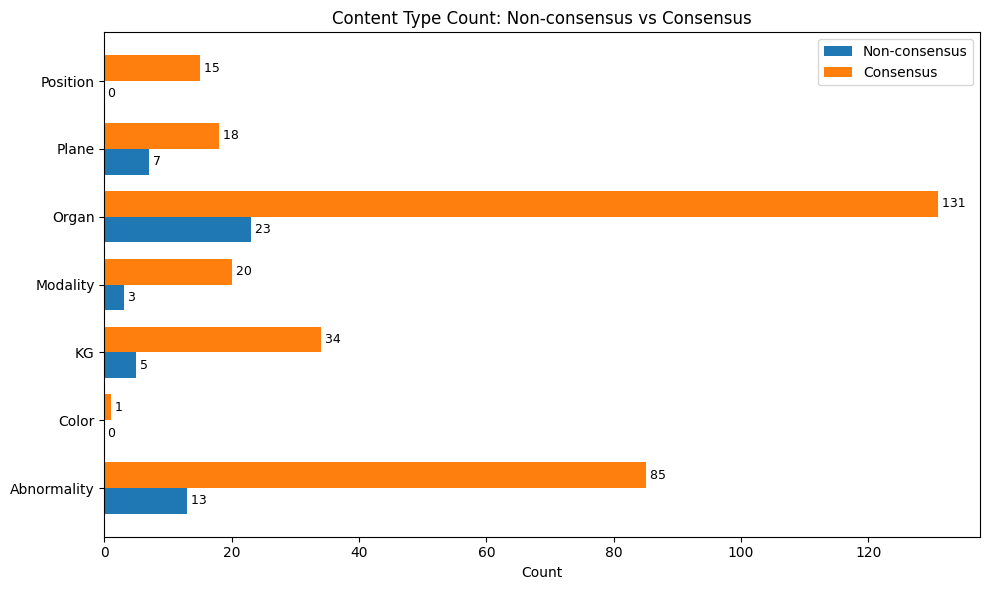

In [8]:
import matplotlib.pyplot as plt
import pandas as pd


def to_count_df(nc_counts, c_counts, category_name):
    labels = sorted(set(nc_counts.keys()) | set(c_counts.keys()))

    df = pd.DataFrame({
        'label': labels,
        'non_consensus': [nc_counts.get(x, 0) for x in labels],
        'consensus': [c_counts.get(x, 0) for x in labels],
    })

    df['gap'] = df['non_consensus'] - df['consensus']
    df['category'] = category_name
    return df


loc_df = to_count_df(nc_df['location'], c_df['location'], 'Location')
mod_df = to_count_df(nc_df['modality'], c_df['modality'], 'Modality')
content_df = to_count_df(nc_df['content_type'], c_df['content_type'], 'Content Type')

def plot_grouped_count_barh(df, title, save_path=None):
    y = range(len(df))
    height = 0.38

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh([i - height/2 for i in y], df['non_consensus'], height=height, label='Non-consensus')
    ax.barh([i + height/2 for i in y], df['consensus'], height=height, label='Consensus')

    ax.set_yticks(list(y))
    ax.set_yticklabels(df['label'])
    ax.set_xlabel('Count')
    ax.set_title(title)
    ax.legend()

    for i, v in enumerate(df['non_consensus']):
        ax.text(v, i - height/2, f' {v}', va='center', fontsize=9)
    for i, v in enumerate(df['consensus']):
        ax.text(v, i + height/2, f' {v}', va='center', fontsize=9)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


plot_grouped_count_barh(content_df, 'Content Type Count: Non-consensus vs Consensus')

In [9]:
metrics_df

,prefix,total,yes,no,tp,fp,tn,fn,acc
0,medgemma_default,51,45,6,21,24,3,3,0.470588
1,medgemma_main_clinician_anger_frustration,51,5,46,4,1,26,20,0.588235
2,medgemma_main_clinician_fear_anxiety,51,27,24,14,13,14,10,0.549020
3,medgemma_main_clinician_neutral,51,45,6,19,26,1,5,0.392157
4,medgemma_main_clinician_sadness_distress,51,21,30,11,10,17,13,0.549020
5,medgemma_main_patient_anger_frustration,51,1,50,1,0,27,23,0.549020
6,medgemma_main_patient_fear_anxiety,51,18,33,10,8,19,14,0.568627
7,medgemma_main_patient_neutral,51,34,17,18,16,11,6,0.568627
8,medgemma_main_patient_sadness_distress,51,15,36,9,6,21,15,0.588235


In [10]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt


input_dir = '/workspace/EmoMedicalVLM/output/MedGemma/scored'

rows = []

for file in sorted(os.listdir(input_dir)):
    prefix = file.split('.')[0]

    with open(os.path.join(input_dir, file), 'r') as f:
        lines = f.readlines()

    for i, line in enumerate(lines):
        if i not in non_consensus_indices:
            continue

        item = json.loads(line)

        rows.append({
            'prefix': prefix,
            'max_score': item['max_prob'],
            'answer_score': item['yes_prob'] if item['answer'] == 'Yes' else item['no_prob'],
        })

df = pd.DataFrame(rows)
print(df.head())

             prefix  max_score  answer_score
0  medgemma_default     0.6196        0.3758
1  medgemma_default     0.9311        0.0049
2  medgemma_default     0.9963        0.9963
3  medgemma_default     0.7936        0.2007
4  medgemma_default     0.8571        0.8571


In [11]:
name_map = {
    'medgemma_default': 'default',
    'medgemma_main_clinician_neutral': 'clin_neutral',
    'medgemma_main_clinician_fear_anxiety': 'clin_fear',
    'medgemma_main_clinician_anger_frustration': 'clin_anger',
    'medgemma_main_clinician_sadness_distress': 'clin_sad',
    'medgemma_main_patient_neutral': 'pat_neutral',
    'medgemma_main_patient_fear_anxiety': 'pat_fear',
    'medgemma_main_patient_anger_frustration': 'pat_anger',
    'medgemma_main_patient_sadness_distress': 'pat_sad',
}

order = [
    'medgemma_default',
    'medgemma_main_clinician_neutral',
    'medgemma_main_clinician_fear_anxiety',
    'medgemma_main_clinician_anger_frustration',
    'medgemma_main_clinician_sadness_distress',
    'medgemma_main_patient_neutral',
    'medgemma_main_patient_fear_anxiety',
    'medgemma_main_patient_anger_frustration',
    'medgemma_main_patient_sadness_distress',
]

summary = (
    df.groupby('prefix')[['max_score', 'answer_score']]
    .mean()
    .reindex(order)
    .reset_index()
)

summary['prefix_short'] = summary['prefix'].map(name_map)
print(summary)

                                      prefix  max_score  answer_score  \
0                           medgemma_default   0.900355      0.470812   
1            medgemma_main_clinician_neutral   0.876947      0.412159   
2       medgemma_main_clinician_fear_anxiety   0.801312      0.503680   
3  medgemma_main_clinician_anger_frustration   0.800408      0.540075   
4   medgemma_main_clinician_sadness_distress   0.786829      0.531004   
5              medgemma_main_patient_neutral   0.792506      0.482161   
6         medgemma_main_patient_fear_anxiety   0.722720      0.501608   
7    medgemma_main_patient_anger_frustration   0.776710      0.502420   
8     medgemma_main_patient_sadness_distress   0.746600      0.513939   

   prefix_short  
0       default  
1  clin_neutral  
2     clin_fear  
3    clin_anger  
4      clin_sad  
5   pat_neutral  
6      pat_fear  
7     pat_anger  
8       pat_sad  


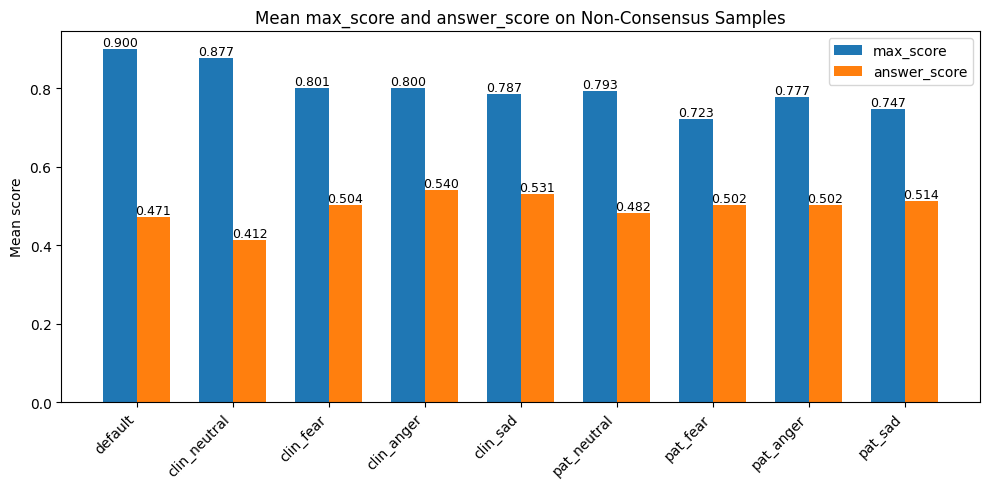

In [12]:
x = range(len(summary))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar([i - width/2 for i in x], summary['max_score'], width=width, label='max_score')
ax.bar([i + width/2 for i in x], summary['answer_score'], width=width, label='answer_score')

ax.set_xticks(list(x))
ax.set_xticklabels(summary['prefix_short'], rotation=45, ha='right')
ax.set_ylabel('Mean score')
ax.set_title('Mean max_score and answer_score on Non-Consensus Samples')
ax.legend()

for i, v in enumerate(summary['max_score']):
    ax.text(i - width/2, v, f'{v:.3f}', ha='center', va='bottom', fontsize=9)
for i, v in enumerate(summary['answer_score']):
    ax.text(i + width/2, v, f'{v:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [15]:
summary = (
    df.groupby('prefix')[['max_score', 'answer_score']]
    .agg(['mean', 'std'])
)

summary.columns = [f'{col}_{stat}' for col, stat in summary.columns]
summary = summary.reset_index()

summary['prefix'] = summary['prefix'].map(name_map)
summary

,prefix,max_score_mean,max_score_std,answer_score_mean,answer_score_std
0,default,0.900355,0.158491,0.470812,0.444898
1,clin_anger,0.800408,0.155173,0.540075,0.377829
2,clin_fear,0.801312,0.152753,0.503680,0.378046
3,clin_neutral,0.876947,0.144363,0.412159,0.423278
4,clin_sad,0.786829,0.156065,0.531004,0.357235
5,pat_anger,0.776710,0.188531,0.502420,0.388334
6,pat_fear,0.722720,0.179910,0.501608,0.345491
7,pat_neutral,0.792506,0.164440,0.482161,0.376567
8,pat_sad,0.746600,0.165282,0.513939,0.345092


In [16]:
corr_df = pd.DataFrame({
    'acc': [0.471, 0.392, 0.549, 0.588, 0.549, 0.569, 0.569, 0.549, 0.588],
    'max_score': [0.900, 0.877, 0.801, 0.800, 0.787, 0.793, 0.723, 0.777, 0.747],
    'answer_score': [0.471, 0.412, 0.504, 0.540, 0.531, 0.482, 0.502, 0.502, 0.514],
})

print(corr_df.corr(method='pearson'))
print(corr_df.corr(method='spearman'))

                   acc  max_score  answer_score
acc           1.000000  -0.813289      0.888485
max_score    -0.813289   1.000000     -0.635886
answer_score  0.888485  -0.635886      1.000000
                   acc  max_score  answer_score
acc           1.000000  -0.615587      0.665389
max_score    -0.615587   1.000000     -0.401677
answer_score  0.665389  -0.401677      1.000000


Direct + Indirect

In [4]:
import os
import json
import pandas as pd


df = {'prefix': [], 'yes':[], 'no':[], 'tp': [], 'fp': [], 'tn': [], 'fn': []}
for file in sorted(os.listdir('/workspace/EmoMedicalVLM/output/MedGemma/closed')):
    if 'eval_' in file:
        with open(os.path.join('/workspace/EmoMedicalVLM/output/MedGemma/closed', file), 'r') as f:
            lines = f.readlines()
            metrics = [0,0,0,0,0,0] # yes, no, tp, fp, tn, fn
            for line in lines:
                line = json.loads(line)
                eval = line['evaluation']
                if eval == 'Yes':
                    metrics[0] += 1
                    if line['answer'] == 'Yes':
                        metrics[2] += 1
                    else:
                        metrics[3] += 1
                elif eval == 'No':
                    metrics[1] += 1
                    if line['answer'] == 'No':
                        metrics[4] += 1
                    else:
                        metrics[5] += 1
            df['prefix'].append(file.split('.')[0])
            df['yes'].append(metrics[0])
            df['no'].append(metrics[1])
            df['tp'].append(metrics[2])
            df['fp'].append(metrics[3])
            df['tn'].append(metrics[4])
            df['fn'].append(metrics[5])

In [5]:
df = pd.DataFrame(df)
df

,prefix,yes,no,tp,fp,tn,fn
0,eval_medgemma_default,196,159,149,47,133,26
1,eval_medgemma_induced_main_clinician_anger_fru...,198,157,146,52,128,29
2,eval_medgemma_induced_main_clinician_fear_anxiety,208,147,152,56,124,23
3,eval_medgemma_induced_main_clinician_neutral,207,148,152,55,125,23
4,eval_medgemma_induced_main_clinician_sadness_d...,205,150,150,55,125,25
5,eval_medgemma_induced_main_patient_anger_frust...,209,146,152,57,123,23
6,eval_medgemma_induced_main_patient_fear_anxiety,203,152,148,55,125,27
7,eval_medgemma_induced_main_patient_neutral,208,147,156,52,128,19
8,eval_medgemma_induced_main_patient_sadness_dis...,209,146,154,55,125,21
9,eval_medgemma_main_clinician_anger_frustration,156,199,132,24,156,43


In [7]:
import os
import json
import pandas as pd


input_dir = '/workspace/EmoMedicalVLM/output/MedGemma/closed'

df = {
    'prefix': [],
    'yes': [],
    'no': [],
    'tp': [],
    'fp': [],
    'tn': [],
    'fn': [],
    'acc': [],
}

# lưu prediction của từng prefix để tính similarity matrix
all_preds = {}

for file in sorted(os.listdir(input_dir)):
    if 'eval_' not in file:
        continue

    file_path = os.path.join(input_dir, file)

    with open(file_path, 'r') as f:
        lines = f.readlines()

    metrics = [0, 0, 0, 0, 0, 0]  # yes, no, tp, fp, tn, fn
    preds = []

    for line in lines:
        line = json.loads(line)
        model_answer = line['model_answer']

        eval_ans = line['evaluation']

        preds.append(eval_ans)

        if eval_ans == 'Yes':
            metrics[0] += 1
            if line['answer'] == 'Yes':
                metrics[2] += 1
            else:
                metrics[3] += 1

        elif eval_ans == 'No':
            metrics[1] += 1
            if line['answer'] == 'No':
                metrics[4] += 1
            else:
                metrics[5] += 1


    prefix = file.split('.')[0]
    total_valid = metrics[0] + metrics[1] 
    acc = (metrics[2] + metrics[4]) / total_valid if total_valid > 0 else 0.0

    df['prefix'].append(prefix)
    df['yes'].append(metrics[0])
    df['no'].append(metrics[1])
    df['tp'].append(metrics[2])
    df['fp'].append(metrics[3])
    df['tn'].append(metrics[4])
    df['fn'].append(metrics[5])
    df['acc'].append(acc)

    all_preds[prefix] = preds


result_df = pd.DataFrame(df)

prefixes = list(all_preds.keys())
sim_matrix = pd.DataFrame(index=prefixes, columns=prefixes, dtype=float)

for p1 in prefixes:
    for p2 in prefixes:
        preds1 = all_preds[p1]
        preds2 = all_preds[p2]

        n = min(len(preds1), len(preds2))
        if n == 0:
            sim = 0.0
        else:
            same = sum(1 for a, b in zip(preds1[:n], preds2[:n]) if a == b)
            sim = same / n

        sim_matrix.loc[p1, p2] = sim


In [8]:
result_df

,prefix,yes,no,tp,fp,tn,fn,acc
0,eval_medgemma_default,196,159,149,47,133,26,0.794366
1,eval_medgemma_induced_main_clinician_anger_fru...,198,157,146,52,128,29,0.771831
2,eval_medgemma_induced_main_clinician_fear_anxiety,208,147,152,56,124,23,0.777465
3,eval_medgemma_induced_main_clinician_neutral,207,148,152,55,125,23,0.780282
4,eval_medgemma_induced_main_clinician_sadness_d...,205,150,150,55,125,25,0.774648
5,eval_medgemma_induced_main_patient_anger_frust...,209,146,152,57,123,23,0.774648
6,eval_medgemma_induced_main_patient_fear_anxiety,203,152,148,55,125,27,0.769014
7,eval_medgemma_induced_main_patient_neutral,208,147,156,52,128,19,0.800000
8,eval_medgemma_induced_main_patient_sadness_dis...,209,146,154,55,125,21,0.785915
9,eval_medgemma_main_clinician_anger_frustration,156,199,132,24,156,43,0.811268


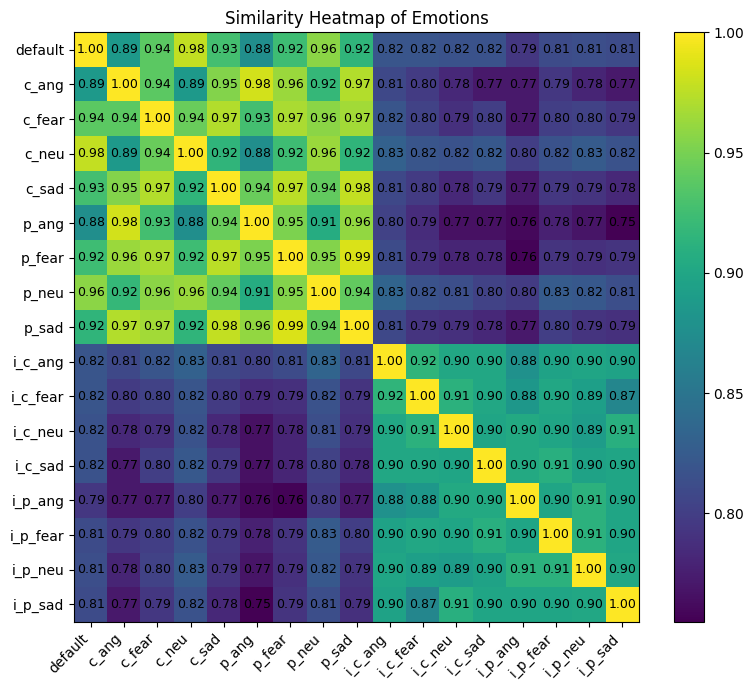

In [10]:
import matplotlib.pyplot as plt

name_map = {
    "eval_medgemma_default": "default",

    "eval_medgemma_induced_main_clinician_anger_frustration": "i_c_ang",
    "eval_medgemma_induced_main_clinician_fear_anxiety": "i_c_fear",
    "eval_medgemma_induced_main_clinician_neutral": "i_c_neu",
    "eval_medgemma_induced_main_clinician_sadness_distress": "i_c_sad",

    "eval_medgemma_induced_main_patient_anger_frustration": "i_p_ang",
    "eval_medgemma_induced_main_patient_fear_anxiety": "i_p_fear",
    "eval_medgemma_induced_main_patient_neutral": "i_p_neu",
    "eval_medgemma_induced_main_patient_sadness_distress": "i_p_sad",

    "eval_medgemma_main_clinician_anger_frustration": "c_ang",
    "eval_medgemma_main_clinician_fear_anxiety": "c_fear",
    "eval_medgemma_main_clinician_neutral": "c_neu",
    "eval_medgemma_main_clinician_sadness_distress": "c_sad",

    "eval_medgemma_main_patient_anger_frustration": "p_ang",
    "eval_medgemma_main_patient_fear_anxiety": "p_fear",
    "eval_medgemma_main_patient_neutral": "p_neu",
    "eval_medgemma_main_patient_sadness_distress": "p_sad",
}

ordered_names = [
    "eval_medgemma_default",

    "eval_medgemma_main_clinician_anger_frustration",
    "eval_medgemma_main_clinician_fear_anxiety",
    "eval_medgemma_main_clinician_neutral",
    "eval_medgemma_main_clinician_sadness_distress",

    "eval_medgemma_main_patient_anger_frustration",
    "eval_medgemma_main_patient_fear_anxiety",
    "eval_medgemma_main_patient_neutral",
    "eval_medgemma_main_patient_sadness_distress",

    "eval_medgemma_induced_main_clinician_anger_frustration",
    "eval_medgemma_induced_main_clinician_fear_anxiety",
    "eval_medgemma_induced_main_clinician_neutral",
    "eval_medgemma_induced_main_clinician_sadness_distress",

    "eval_medgemma_induced_main_patient_anger_frustration",
    "eval_medgemma_induced_main_patient_fear_anxiety",
    "eval_medgemma_induced_main_patient_neutral",
    "eval_medgemma_induced_main_patient_sadness_distress",
]

# reorder matrix
sim_matrix = sim_matrix.loc[ordered_names, ordered_names]

# rename labels
sim_matrix_plot = sim_matrix.copy()
sim_matrix_plot.index = [name_map[x] for x in sim_matrix_plot.index]
sim_matrix_plot.columns = [name_map[x] for x in sim_matrix_plot.columns]

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(sim_matrix_plot.values, interpolation='nearest', aspect='auto')
fig.colorbar(im, ax=ax)

ax.set_xticks(range(len(sim_matrix_plot.columns)))
ax.set_yticks(range(len(sim_matrix_plot.index)))
ax.set_xticklabels(sim_matrix_plot.columns, rotation=45, ha='right')
ax.set_yticklabels(sim_matrix_plot.index)

for i in range(len(sim_matrix_plot.index)):
    for j in range(len(sim_matrix_plot.columns)):
        ax.text(j, i, f'{sim_matrix_plot.iloc[i, j]:.2f}', ha='center', va='center', fontsize=9)

ax.set_title('Similarity Heatmap of Emotions')
plt.tight_layout()
plt.show()

In [18]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt


input_dir = '/workspace/EmoMedicalVLM/output/MedGemma/closed'


def compute_metrics(preds, gts):
    yes = sum(p == 'Yes' for p in preds)
    no = sum(p == 'No' for p in preds)
    undecided = sum(p == 'Undecided' for p in preds)

    tp = sum((p == 'Yes') and (g == 'Yes') for p, g in zip(preds, gts))
    fp = sum((p == 'Yes') and (g == 'No') for p, g in zip(preds, gts))
    tn = sum((p == 'No') and (g == 'No') for p, g in zip(preds, gts))
    fn = sum((p == 'No') and (g == 'Yes') for p, g in zip(preds, gts))

    total_valid = yes + no
    acc = (tp + tn) / total_valid if total_valid else 0.0

    return {
        'yes': yes,
        'no': no,
        'undecided': undecided,
        'tp': tp,
        'fp': fp,
        'tn': tn,
        'fn': fn,
        'acc': acc,
        'total': len(preds),
    }


all_preds = {}
all_gts = None

for file in sorted(os.listdir(input_dir)):
    if 'eval_' not in file:
        continue

    path = os.path.join(input_dir, file)

    preds = []
    gts = []

    with open(path, 'r') as f:
        for line in f:
            item = json.loads(line)
            preds.append(item['evaluation'])
            gts.append(item['answer'])

    prefix = file.split('.')[0]
    all_preds[prefix] = preds

    if all_gts is None:
        all_gts = gts


# cắt về cùng độ dài
n = min(len(v) for v in all_preds.values())
all_gts = all_gts[:n]
all_preds = {k: v[:n] for k, v in all_preds.items()}

prefixes = list(all_preds.keys())


# lấy non-consensus indices
non_consensus_indices = []
for i in range(n):
    labels = [all_preds[prefix][i] for prefix in prefixes]
    if len(set(labels)) > 1:
        non_consensus_indices.append(i)

print(f'total samples: {n}')
print(f'non-consensus samples: {len(non_consensus_indices)}')
print(f'non-consensus ratio: {len(non_consensus_indices) / n:.4f}')


# metric trên non-consensus
rows = []
for prefix in prefixes:
    preds_nc = [all_preds[prefix][i] for i in non_consensus_indices]
    gts_nc = [all_gts[i] for i in non_consensus_indices]

    metrics = compute_metrics(preds_nc, gts_nc)
    metrics['prefix'] = prefix
    rows.append(metrics)

metrics_df = pd.DataFrame(rows)
metrics_df = metrics_df[['prefix', 'total', 'yes', 'no', 'tp', 'fp', 'tn', 'fn', 'acc']]

# print('\n=== Metrics on non-consensus samples ===')
# print(metrics_df)


# similarity matrix trên non-consensus
sim_matrix = pd.DataFrame(index=prefixes, columns=prefixes, dtype=float)

for p1 in prefixes:
    preds1 = [all_preds[p1][i] for i in non_consensus_indices]
    for p2 in prefixes:
        preds2 = [all_preds[p2][i] for i in non_consensus_indices]
        m = len(preds1)
        sim = sum(a == b for a, b in zip(preds1, preds2)) / m if m else 0.0
        sim_matrix.loc[p1, p2] = sim

# print('\n=== Similarity matrix on non-consensus samples ===')
# print(sim_matrix)


non_consensus_df = pd.DataFrame({
    'sample_index': non_consensus_indices,
    'ground_truth': [all_gts[i] for i in non_consensus_indices],
})


total samples: 355
non-consensus samples: 137
non-consensus ratio: 0.3859


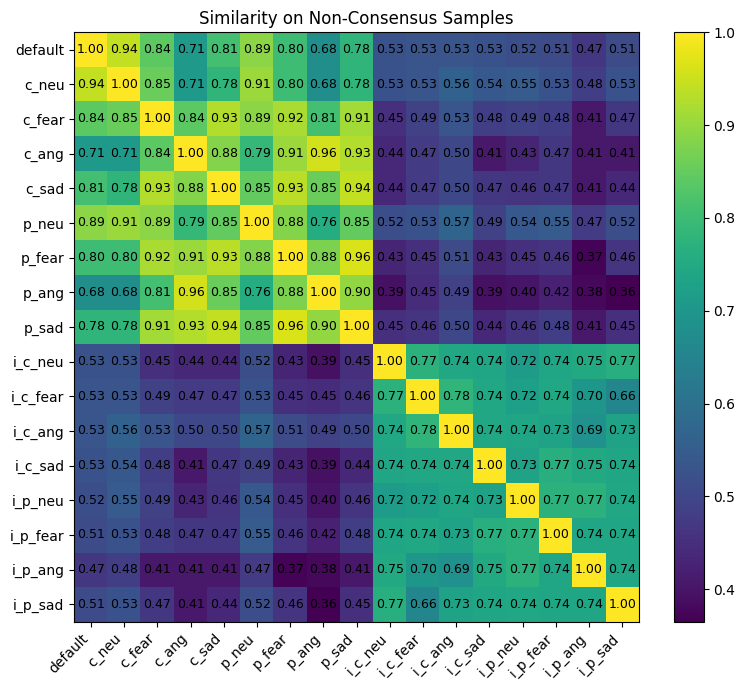

In [21]:
name_map = {
    "eval_medgemma_default": "default",

    "eval_medgemma_induced_main_clinician_anger_frustration": "i_c_ang",
    "eval_medgemma_induced_main_clinician_fear_anxiety": "i_c_fear",
    "eval_medgemma_induced_main_clinician_neutral": "i_c_neu",
    "eval_medgemma_induced_main_clinician_sadness_distress": "i_c_sad",

    "eval_medgemma_induced_main_patient_anger_frustration": "i_p_ang",
    "eval_medgemma_induced_main_patient_fear_anxiety": "i_p_fear",
    "eval_medgemma_induced_main_patient_neutral": "i_p_neu",
    "eval_medgemma_induced_main_patient_sadness_distress": "i_p_sad",

    "eval_medgemma_main_clinician_anger_frustration": "c_ang",
    "eval_medgemma_main_clinician_fear_anxiety": "c_fear",
    "eval_medgemma_main_clinician_neutral": "c_neu",
    "eval_medgemma_main_clinician_sadness_distress": "c_sad",

    "eval_medgemma_main_patient_anger_frustration": "p_ang",
    "eval_medgemma_main_patient_fear_anxiety": "p_fear",
    "eval_medgemma_main_patient_neutral": "p_neu",
    "eval_medgemma_main_patient_sadness_distress": "p_sad",
}

ordered_names = [
    "eval_medgemma_default",
    
    "eval_medgemma_main_clinician_neutral",
    "eval_medgemma_main_clinician_fear_anxiety",
    "eval_medgemma_main_clinician_anger_frustration",
    "eval_medgemma_main_clinician_sadness_distress",

    "eval_medgemma_main_patient_neutral",
    "eval_medgemma_main_patient_fear_anxiety",
    "eval_medgemma_main_patient_anger_frustration",
    "eval_medgemma_main_patient_sadness_distress",

    "eval_medgemma_induced_main_clinician_neutral",
    "eval_medgemma_induced_main_clinician_fear_anxiety",
    "eval_medgemma_induced_main_clinician_anger_frustration",
    "eval_medgemma_induced_main_clinician_sadness_distress",

    "eval_medgemma_induced_main_patient_neutral",
    "eval_medgemma_induced_main_patient_fear_anxiety",
    "eval_medgemma_induced_main_patient_anger_frustration",
    "eval_medgemma_induced_main_patient_sadness_distress",
]

# reorder matrix
sim_matrix = sim_matrix.loc[ordered_names, ordered_names]

# rename labels
sim_matrix_plot = sim_matrix.copy()
sim_matrix_plot.index = [name_map[x] for x in sim_matrix_plot.index]
sim_matrix_plot.columns = [name_map[x] for x in sim_matrix_plot.columns]

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(sim_matrix_plot.values, interpolation='nearest', aspect='auto')
fig.colorbar(im, ax=ax)

ax.set_xticks(range(len(sim_matrix_plot.columns)))
ax.set_yticks(range(len(sim_matrix_plot.index)))
ax.set_xticklabels(sim_matrix_plot.columns, rotation=45, ha='right')
ax.set_yticklabels(sim_matrix_plot.index)

for i in range(len(sim_matrix_plot.index)):
    for j in range(len(sim_matrix_plot.columns)):
        ax.text(j, i, f'{sim_matrix_plot.iloc[i, j]:.2f}', ha='center', va='center', fontsize=9)

ax.set_title('Similarity on Non-Consensus Samples')
plt.tight_layout()
plt.show()

In [22]:
metrics_df

,prefix,total,yes,no,tp,fp,tn,fn,acc
0,eval_medgemma_default,137,75,62,39,36,42,20,0.591241
1,eval_medgemma_induced_main_clinician_anger_fru...,137,77,60,36,41,37,23,0.532847
2,eval_medgemma_induced_main_clinician_fear_anxiety,137,87,50,42,45,33,17,0.547445
3,eval_medgemma_induced_main_clinician_neutral,137,86,51,42,44,34,17,0.554745
4,eval_medgemma_induced_main_clinician_sadness_d...,137,84,53,40,44,34,19,0.540146
5,eval_medgemma_induced_main_patient_anger_frust...,137,88,49,42,46,32,17,0.540146
6,eval_medgemma_induced_main_patient_fear_anxiety,137,82,55,38,44,34,21,0.525547
7,eval_medgemma_induced_main_patient_neutral,137,87,50,46,41,37,13,0.605839
8,eval_medgemma_induced_main_patient_sadness_dis...,137,88,49,44,44,34,15,0.569343
9,eval_medgemma_main_clinician_anger_frustration,137,35,102,22,13,65,37,0.635036
